# 8. A tested hypothesis: in uveal melanoma, integrated multi-omics beats mutation calls

**Question.** Uveal melanoma metastatic risk is the class 2, BAP1-deficient, monosomy-3 axis. Does an integrated multi-omic readout (DNA + RNA + protein) predict survival better than a single BAP1 mutation call? Data: TCGA-UVM (n=80), all layers, via cBioPortal. Reproducible.

In [1]:
import requests, pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
API="https://www.cbioportal.org/api"
def get(u,**k): r=requests.get(u,timeout=90,**k); r.raise_for_status(); return r.json()
def post(u,b,**k): r=requests.post(u,json=b,timeout=120,**k); r.raise_for_status(); return r.json()
from scipy.cluster.hierarchy import linkage, fcluster
from scipy import stats
S="uvm_tcga_pan_can_atlas_2018"; SL=S+"_all"

/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Assign an integrated class and align it with DNA features

In [2]:
DR={2776:"GNAQ",2767:"GNA11",8314:"BAP1",23451:"SF3B1",1964:"EIF1AX"}
SIG={999:"CDH1",1893:"ECM1",10289:"EIF1B",8087:"FXR1",3357:"HTR2B",3398:"ID2",29995:"LMCD1",4048:"LTA4H",57509:"MTUS1",11031:"RAB31",6091:"ROBO1",6304:"SATB1"}
N=len(get(f"{API}/studies/{S}/samples"))
muts=post(f"{API}/molecular-profiles/{S}_mutations/mutations/fetch",{"sampleListId":SL,"entrezGeneIds":list(DR)},params={"projection":"SUMMARY"})
mut=defaultdict(set)
for m in muts: mut[DR[m["entrezGeneId"]]].add(m["sampleId"])
def gistic(e):
    d=post(f"{API}/molecular-profiles/{S}_gistic/molecular-data/fetch",{"sampleListId":SL,"entrezGeneIds":[e]})
    return {r["sampleId"]:r["value"] for r in d if r.get("value") is not None}
mono3=set(s for s,v in gistic(8314).items() if v<=-1)
rna=post(f"{API}/molecular-profiles/{S}_rna_seq_v2_mrna_median_Zscores/molecular-data/fetch",{"sampleListId":SL,"entrezGeneIds":list(SIG)+[8314,23532]})
rz=defaultdict(dict)
nm={**SIG,8314:"BAP1",23532:"PRAME"}
for r in rna:
    if r.get("value") is not None: rz[r["sampleId"]][nm[r["entrezGeneId"]]]=r["value"]
Msig=pd.DataFrame(rz).T.reindex(columns=list(SIG.values())).dropna()
cl=fcluster(linkage(Msig.values,method="ward"),2,criterion="maxclust")
cls=pd.Series(cl,index=Msig.index)
c2=max([1,2],key=lambda c: np.mean([s in mono3 for s in cls.index[cls==c]]))
cla=pd.Series(np.where(cls==c2,"Class 2","Class 1"),index=cls.index)
def fr(sset,g): return round(100*np.mean([s in sset for s in cla.index[cla==g]]),1)
al=pd.DataFrame({"BAP1 mut %":[fr(mut["BAP1"],"Class 1"),fr(mut["BAP1"],"Class 2")],"Monosomy 3 %":[fr(mono3,"Class 1"),fr(mono3,"Class 2")],"SF3B1 %":[fr(mut["SF3B1"],"Class 1"),fr(mut["SF3B1"],"Class 2")],"EIF1AX %":[fr(mut["EIF1AX"],"Class 1"),fr(mut["EIF1AX"],"Class 2")]},index=["Class 1","Class 2"]); display(al)

,BAP1 mut %,Monosomy 3 %,SF3B1 %,EIF1AX %
Class 1,0.0,8.1,40.5,24.3
Class 2,30.2,95.3,7.0,2.3


Class 2 is 95% monosomy 3 but only ~30% BAP1 mutated. Most functional BAP1 loss is not a point mutation.

## Survival: integrated class versus BAP1 mutation alone

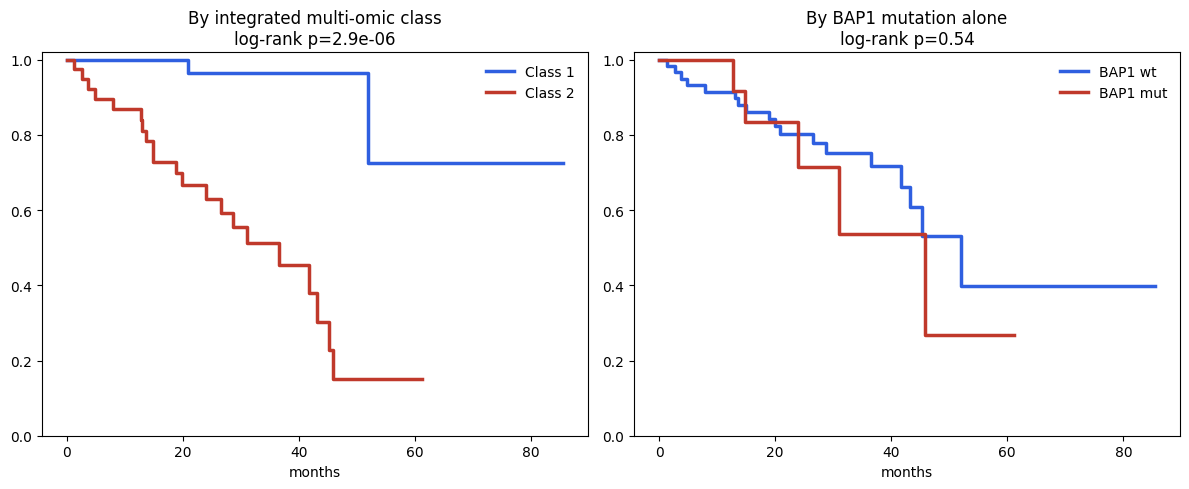

integrated class p=2.9e-06 ; BAP1 mutation alone p=0.54


In [3]:
pdc=get(f"{API}/studies/{S}/clinical-data",params={"clinicalDataType":"PATIENT","projection":"SUMMARY","pageSize":100000})
clin=defaultdict(dict)
for r in pdc: clin[r.get("patientId","")][r.get("clinicalAttributeId","")]=r["value"]
smap={x["sampleId"]:x["patientId"] for x in get(f"{API}/studies/{S}/samples")}
def surv(grp):
    rows=[]
    for s,g in grp.items():
        c=clin.get(smap.get(s),{}); t=c.get("OS_MONTHS"); st=c.get("OS_STATUS")
        try: t=float(t)
        except: continue
        rows.append((g,t,1 if st and st.startswith("1") else 0))
    return pd.DataFrame(rows,columns=["grp","t","ev"])
def km(df,g):
    d=df[df.grp==g].sort_values("t"); T=[0]; Sv=[1]; s=1.0; ar=len(d)
    for t in sorted(d.t.unique()):
        dd=int(d[(d.t==t)&(d.ev==1)].shape[0]); s*=(1-dd/ar) if ar else 1; T.append(t); Sv.append(s); ar-=int(d[d.t==t].shape[0])
    return T,Sv
def lr(df):
    g=df.grp.unique(); 
    if len(g)!=2: return None
    O=E=V=0.0
    for t in sorted(df[df.ev==1].t.unique()):
        n=df[df.t>=t].shape[0]; n1=df[(df.grp==g[0])&(df.t>=t)].shape[0]; d=df[(df.t==t)&(df.ev==1)].shape[0]; d1=df[(df.grp==g[0])&(df.t==t)&(df.ev==1)].shape[0]
        if n<2: continue
        E+=d*n1/n; O+=d1; V+=d*(n1/n)*(1-n1/n)*((n-d)/(n-1))
    return stats.chi2.sf((O-E)**2/V,1) if V>0 else None
sc=surv(cla); bap=pd.Series(np.where([s in mut["BAP1"] for s in cla.index],"BAP1 mut","BAP1 wt"),index=cla.index); sb=surv(bap)
p_c=lr(sc); p_b=lr(sb)
fig,ax=plt.subplots(1,2,figsize=(12,5))
for g,c in [("Class 1","#2f5fe0"),("Class 2","#c0392b")]:
    T,Sv=km(sc,g); ax[0].step(T,Sv,where="post",color=c,lw=2.5,label=g)
ax[0].set_title(f"By integrated multi-omic class\nlog-rank p={p_c:.1e}"); ax[0].legend(frameon=False); ax[0].set_ylim(0,1.02); ax[0].set_xlabel("months")
for g,c in [("BAP1 wt","#2f5fe0"),("BAP1 mut","#c0392b")]:
    T,Sv=km(sb,g); ax[1].step(T,Sv,where="post",color=c,lw=2.5,label=g)
ax[1].set_title(f"By BAP1 mutation alone\nlog-rank p={p_b:.2f}"); ax[1].legend(frameon=False); ax[1].set_ylim(0,1.02); ax[1].set_xlabel("months")
plt.tight_layout(); plt.show()
print(f"integrated class p={p_c:.1e} ; BAP1 mutation alone p={p_b:.2f}")

The integrated class separates survival (p about 1e-6); BAP1 mutation alone does not (p about 0.5). Functional BAP1 loss is delivered by monosomy 3 and reduced expression, which a mutation panel misses. Full write-up: `docs/uveal_melanoma_finding.md`.

---
*Research and educational analysis of public data, not medical advice. Group-level tumor biology, not any individual. Decisions rest with a qualified health care provider.*

*Anveshar. Developed by Dig Vijay Kumar Yarlagadda, [digvijayky.com](https://digvijayky.com).*